In [1]:
import os
import shutil

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
#import torch.nn.functional as F
import time


def cycle_graph(G):
    if not nx.is_connected(G):
        return False

    # Vérifie que chaque nœud a un degré de 2
    if not all(degree == 2 for _, degree in G.degree()):
        return False

    return True

# Fonction pour calculer le pourcentage de graphes correctes (qui correspondent à fct)
def calculate_correct_graphs(fake_matrices, threshold=0.5, fct=cycle_graph):
    correct_count = 0
    for fake_matrix in fake_matrices:
        binary_matrix = (fake_matrix > threshold).astype(int)
        G = nx.from_numpy_array(binary_matrix)
        if fct(G):
            correct_count += 1
    return correct_count / len(fake_matrices) * 100

# Fonction pour calculer le pourcentage de graphes différents
def calculate_different_graphs(fake_matrices, threshold=0.5):
    unique_graphs = set()
    for fake_matrix in fake_matrices:
        binary_matrix = (fake_matrix > threshold).astype(int)
        #G = nx.from_numpy_array(binary_matrix)
        unique_graphs.add(binary_matrix.tostring())  # Représentation unique
    return len(unique_graphs) / len(fake_matrices) * 100


<ipython-input-2-19f8126d1fba>:167: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  real_graphs = torch.tensor(graph_dataset[i:i+batch_size], dtype=torch.float32).to(device)
<ipython-input-1-c49c39dec057>:40: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  unique_graphs.add(binary_matrix.tostring())  # Représentation unique


Epoch [0/4000], d_loss: 1.3530, g_loss: 95.6827, degree_penalty: 1909.8994, connectivity_penalty: 0.0000
Epoch [100/4000], d_loss: 0.9001, g_loss: 2.3323, degree_penalty: 46.4179, connectivity_penalty: 0.0000
Epoch [200/4000], d_loss: 0.4241, g_loss: 2.1583, degree_penalty: 48.2407, connectivity_penalty: 0.0000
Epoch [300/4000], d_loss: 0.1327, g_loss: 0.9305, degree_penalty: 27.1482, connectivity_penalty: 0.0000
Epoch [400/4000], d_loss: 0.0309, g_loss: -0.0272, degree_penalty: 11.5518, connectivity_penalty: 0.0000
Epoch [500/4000], d_loss: 0.0102, g_loss: -0.1272, degree_penalty: 13.7528, connectivity_penalty: 0.0000
Epoch [600/4000], d_loss: 0.0034, g_loss: -0.7570, degree_penalty: 5.0935, connectivity_penalty: 0.0000
Epoch [700/4000], d_loss: 0.0017, g_loss: -0.8463, degree_penalty: 4.8752, connectivity_penalty: 0.0000
Epoch [800/4000], d_loss: 0.0011, g_loss: -1.0170, degree_penalty: 4.5952, connectivity_penalty: 0.0000
Epoch [900/4000], d_loss: 0.0005, g_loss: -1.1659, degree_pen

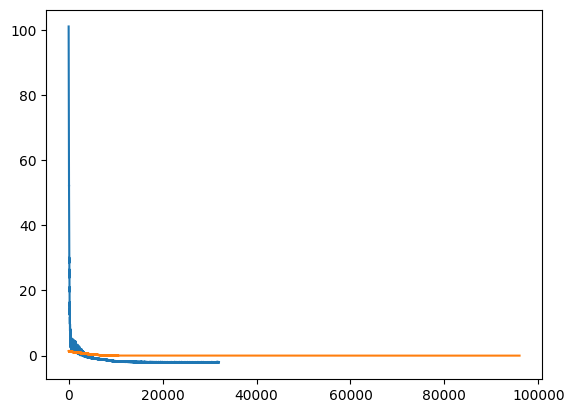

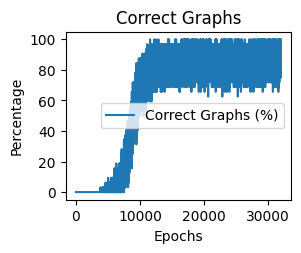

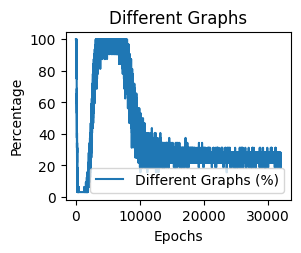


    Temps :  2728.205351829529


<ipython-input-2-19f8126d1fba>:270: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load('generator_cycle.pth'))


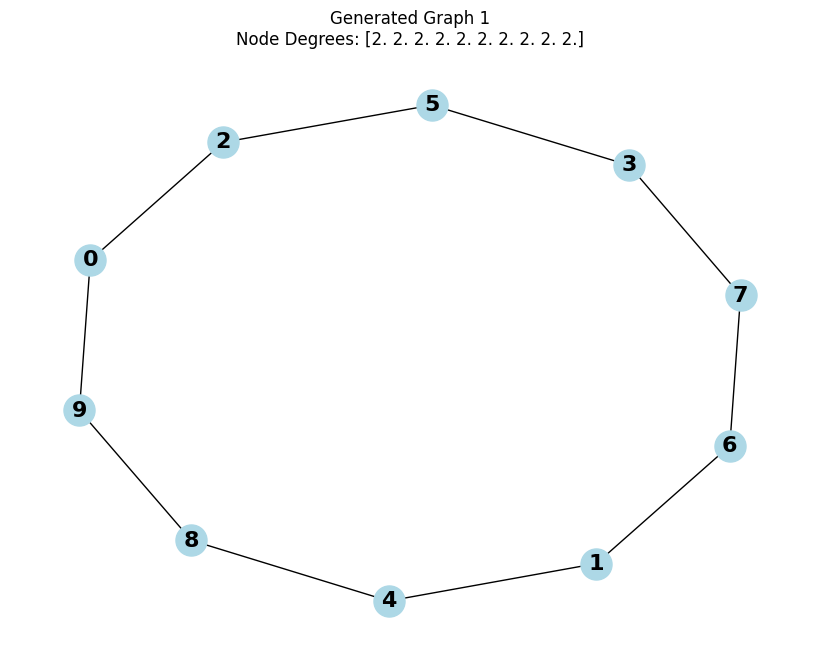

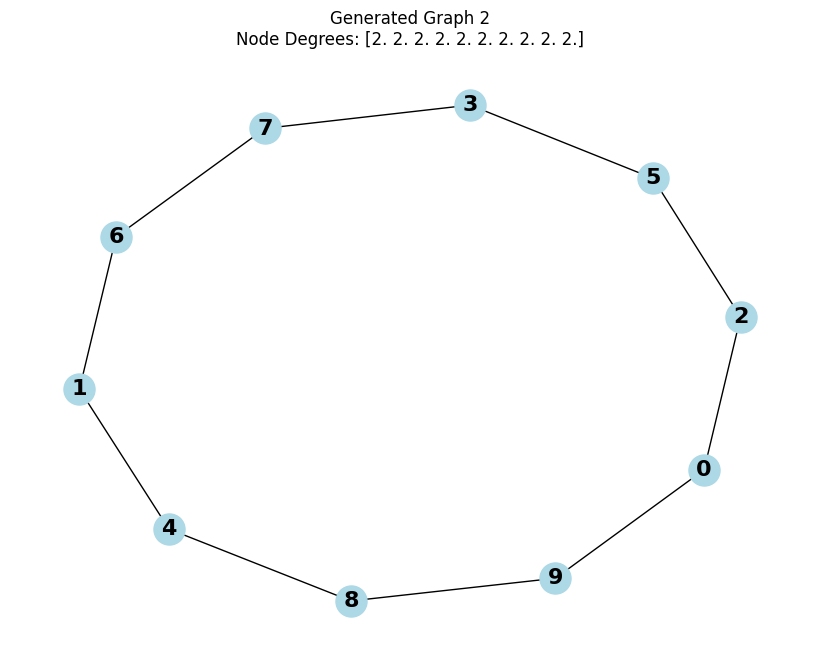

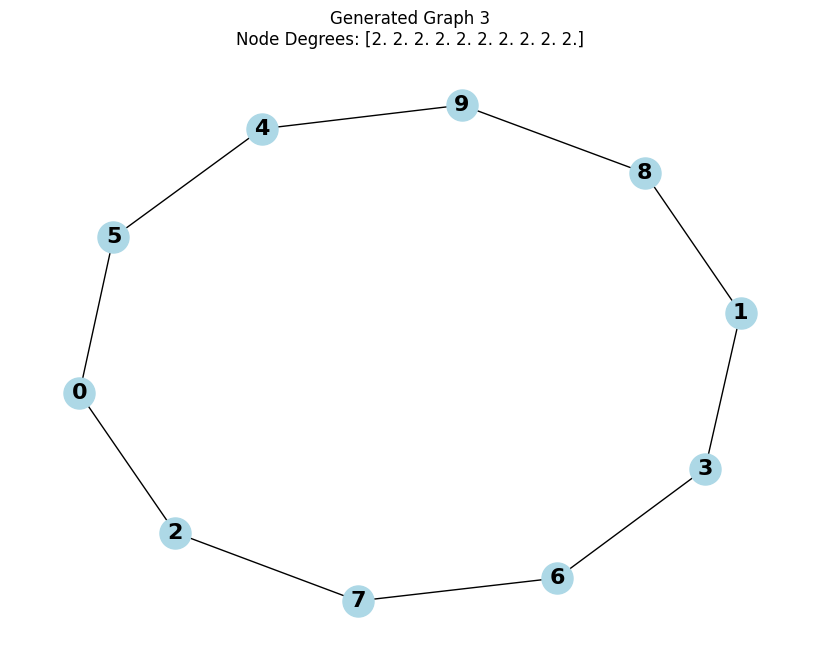

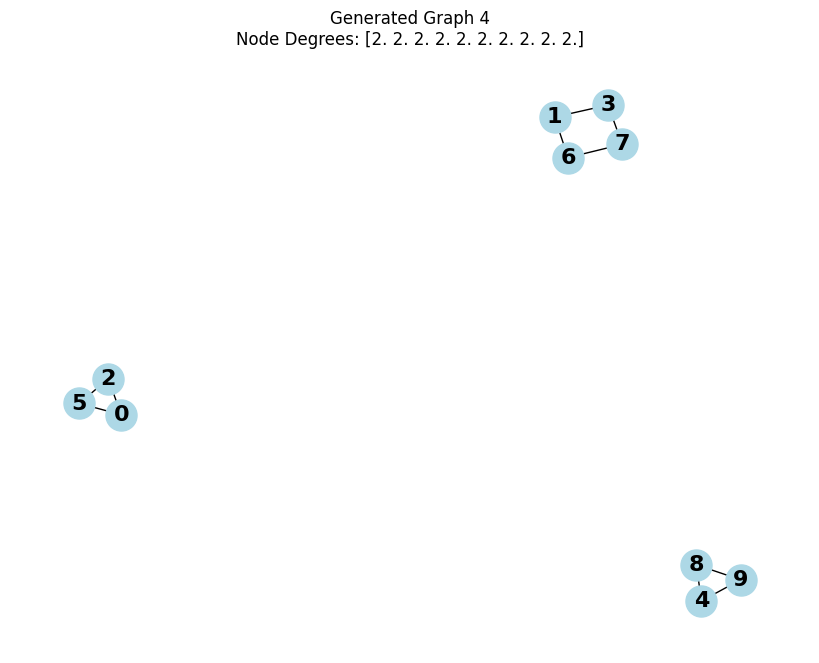

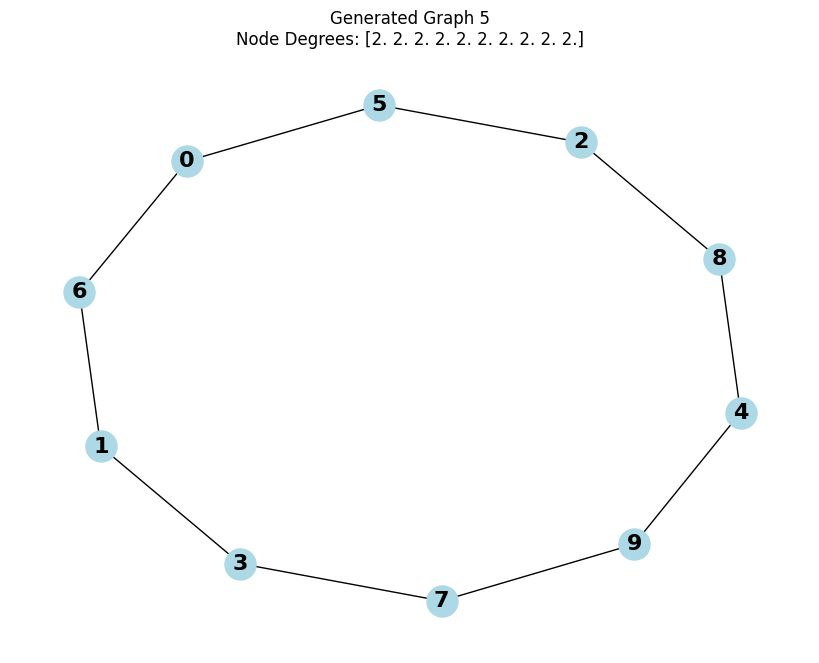

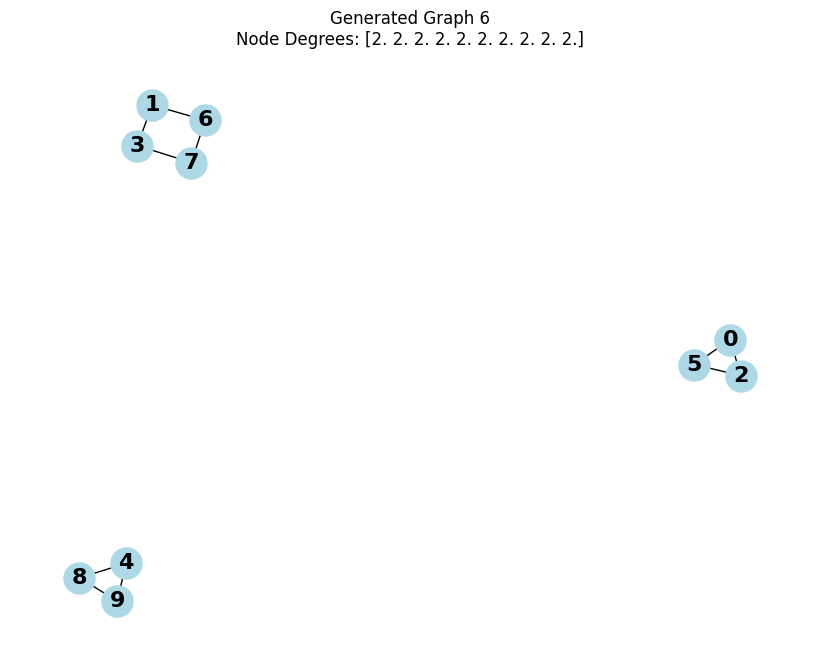

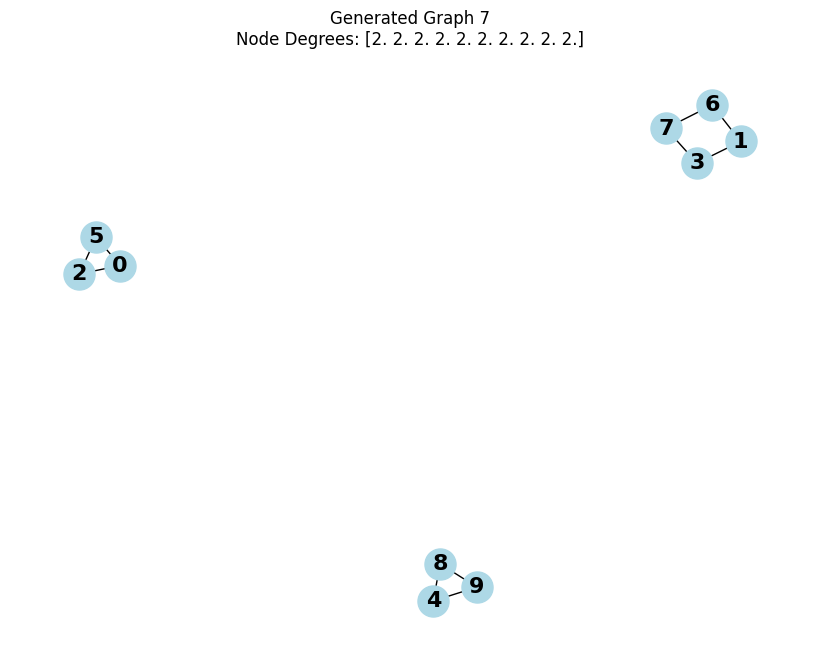

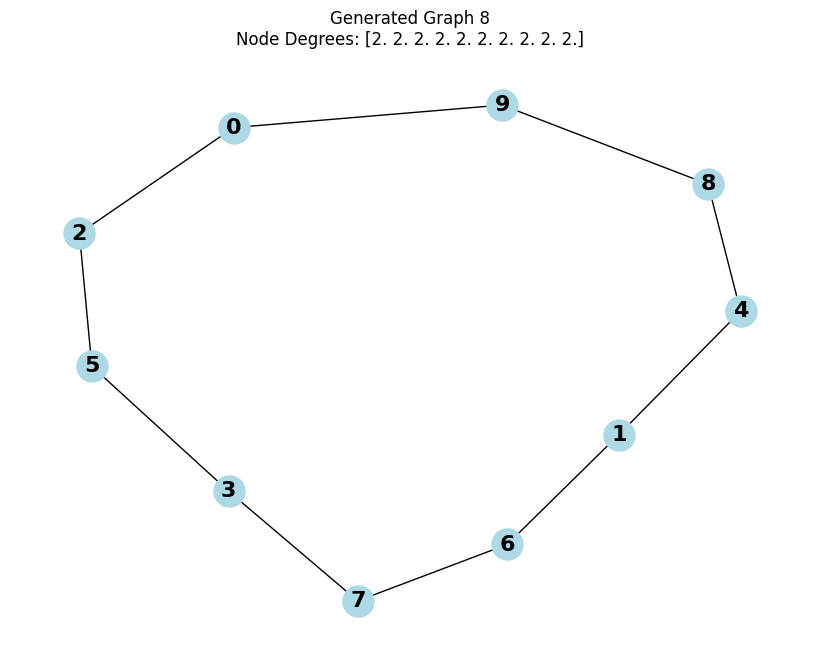

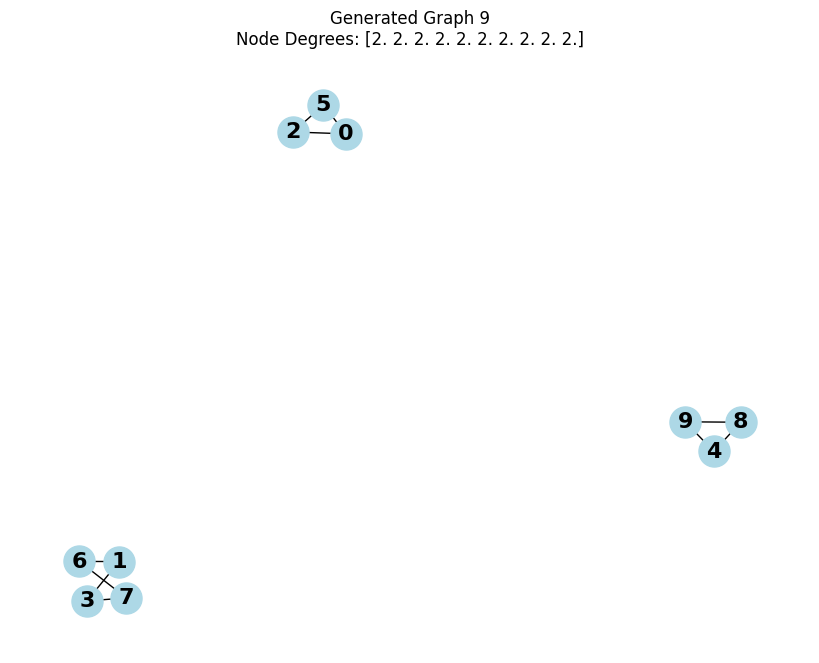

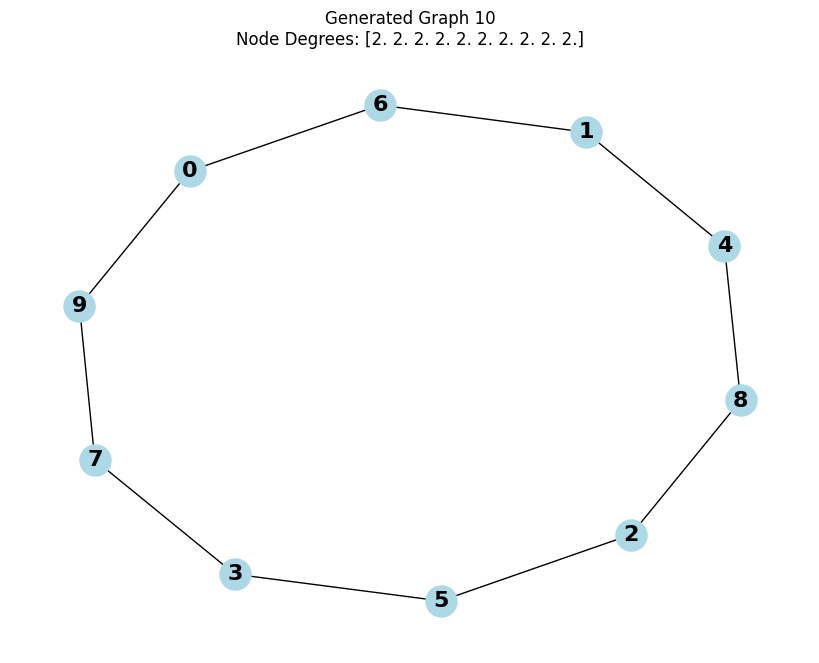

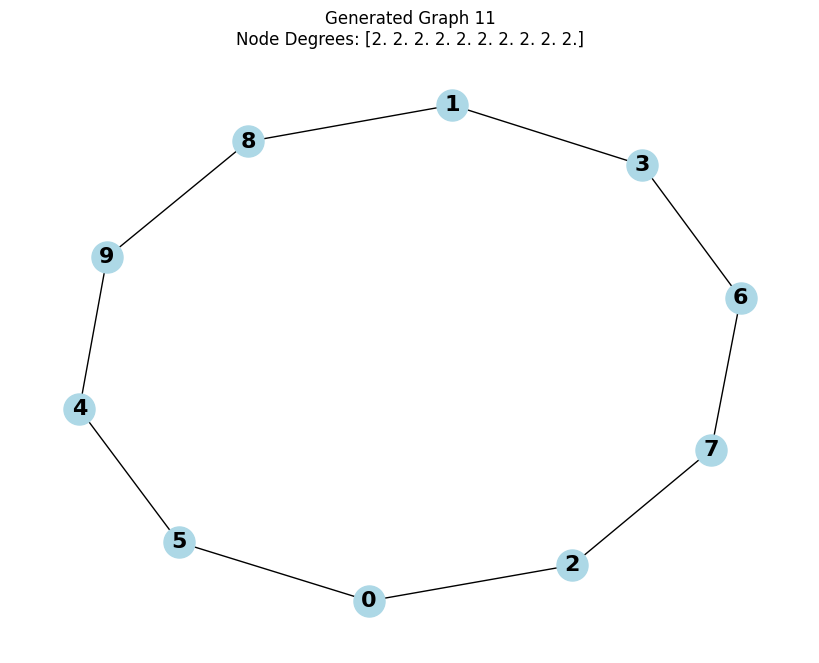

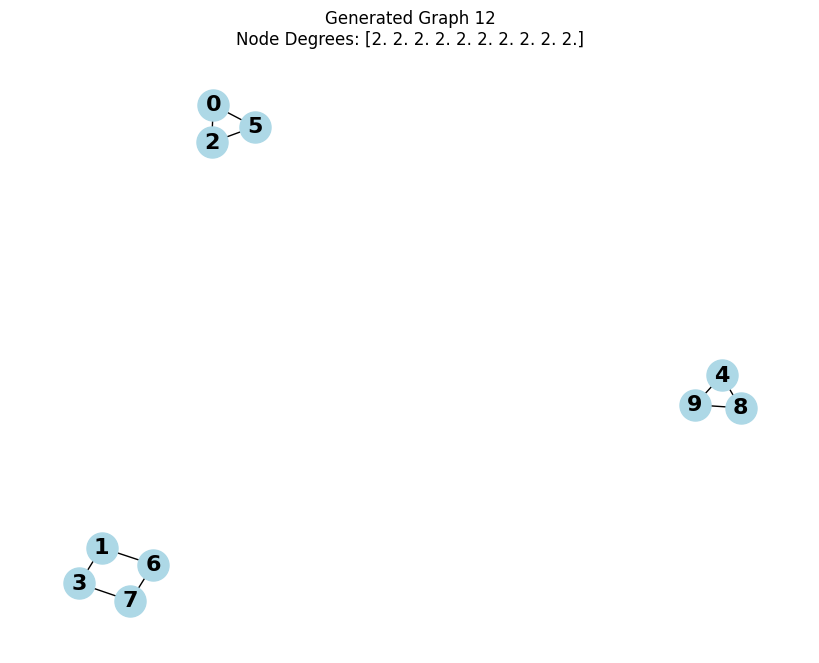

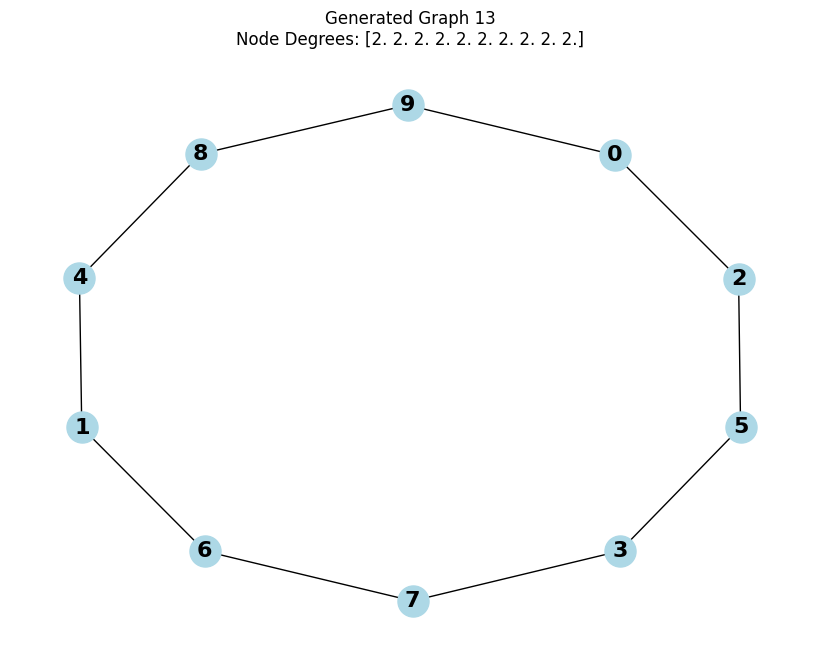

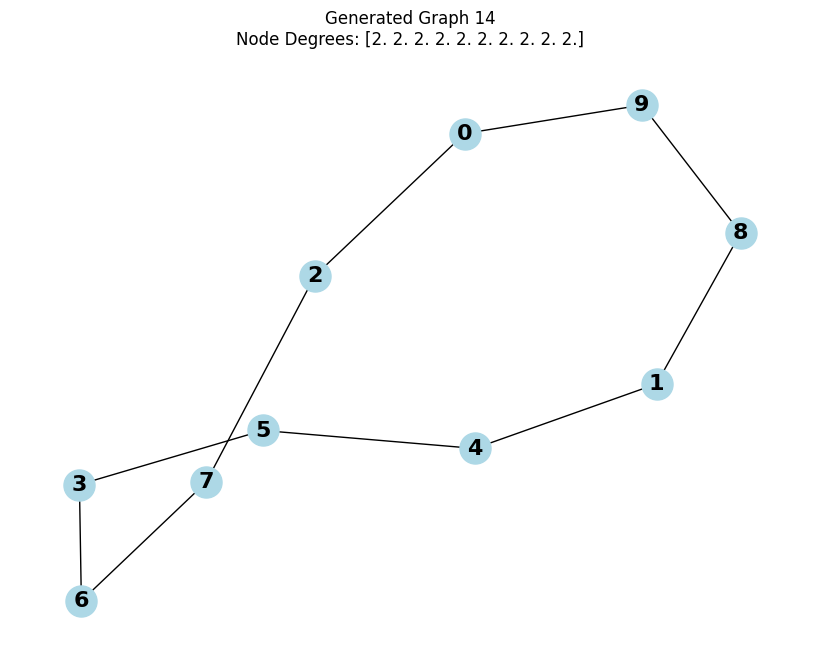

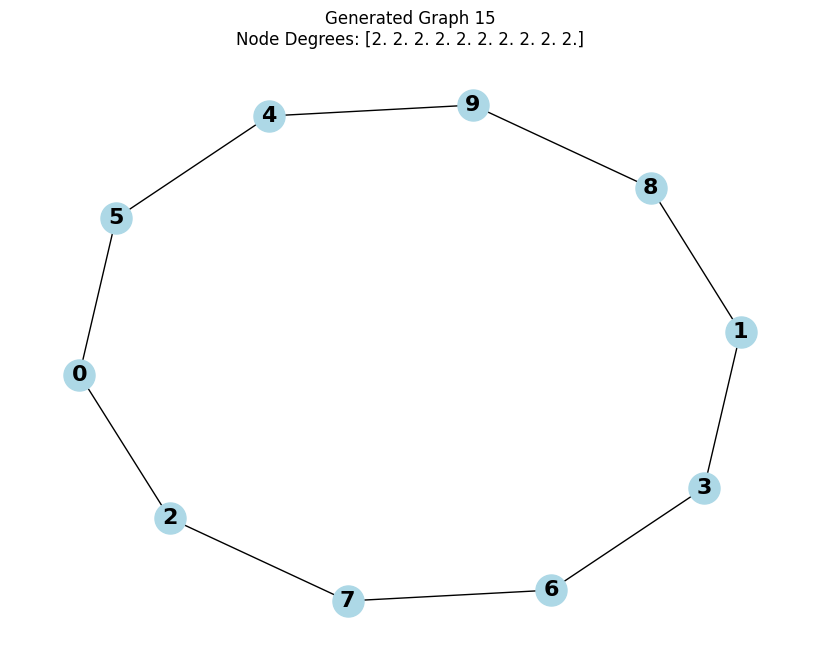

In [2]:
#from arbres import calculate_different_graphs, calculate_correct_graphs, cycle_graph


if os.path.exists('generated_graphs'):
    shutil.rmtree('generated_graphs')  # Supprime tout le dossier et son contenu
os.makedirs('generated_graphs', exist_ok=True)  # Recrée un répertoire vide


def generate_random_cycle_graph(n):
    G = nx.Graph()
    G.add_nodes_from(range(n))

    # Mélanger les sommets de manière aléatoire
    nodes = list(G.nodes())
    np.random.shuffle(nodes)

    # Ajouter des arêtes pour former un cycle
    edges = [(nodes[i], nodes[(i + 1) % n]) for i in range(n)]
    G.add_edges_from(edges)

    adj_matrix = nx.to_numpy_array(G)

    return adj_matrix


# Enregistrer les graphes dans le dataset
def save_graphs(graph_dataset, n_graphs, n_nodes):
    for i in range(n_graphs):
        adj_matrix = graph_dataset[i].reshape(n_nodes, n_nodes)
        G = nx.from_numpy_array(adj_matrix)

        # Créer un fichier d'image pour chaque graphe
        if i % 10_000 == 0:
            plt.figure(figsize=(8, 6))
            try:
                nx.draw_planar(G, with_labels=True, node_color="lightblue", font_weight="bold", node_size=700, edge_color="gray")
            except nx.NetworkXException:
                # Si le graphe n'est pas planaire, utiliser un autre layout
                nx.draw(G, with_labels=True, node_color="lightblue", font_weight="bold", node_size=700, edge_color="gray")

            plt.title(f"Graphe {i + 1}")
            plt.show()

        # Enregistrer l'image dans le dossier 'generated_graphs'
        #plt.savefig(f'generated_graphs/graph_{i + 1}.png')
        plt.close()  # Fermer la figure pour libérer de la mémoire




class DegreeLayer(nn.Module):
    def __init__(self, n_nodes):
        super(DegreeLayer, self).__init__()
        self.n_nodes = n_nodes
        self.sum_layer = nn.Linear(n_nodes, 1, bias=False)
        # Set weights to 1 and freeze them
        self.sum_layer.weight.data.fill_(1)
        self.sum_layer.weight.requires_grad = False

    def forward(self, adj_matrix):
        batch_size = adj_matrix.size(0)
        degrees = torch.zeros(batch_size, self.n_nodes).to(adj_matrix.device)
        for i in range(self.n_nodes):
            degrees[:, i] = self.sum_layer(adj_matrix[:, i, :]).squeeze()
        return degrees

class Generator(nn.Module):
    def __init__(self, n_nodes):
        super(Generator, self).__init__()
        self.n_nodes = n_nodes
        self.fc = nn.Sequential(
            nn.Linear(n_nodes, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, n_nodes * n_nodes)
        )

    def forward(self, z):
        output = self.fc(z)
        adj_matrix = output.view(-1, self.n_nodes, self.n_nodes)
        adj_matrix = (adj_matrix + adj_matrix.transpose(1, 2)) / 2
        adj_matrix = torch.sigmoid(adj_matrix)
        adj_matrix = adj_matrix * (1 - torch.eye(self.n_nodes)).to(adj_matrix.device)
        #adj_matrix = (adj_matrix > 0.5).float()
        return adj_matrix

class Discriminator(nn.Module):
    def __init__(self, n_nodes):
        super(Discriminator, self).__init__()
        self.n_nodes = n_nodes
        self.fc = nn.Sequential(
            nn.Linear(n_nodes * n_nodes, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, adj_matrix):
        x = adj_matrix.view(-1, self.n_nodes * self.n_nodes)
        return self.fc(x)

def connectivity_loss(adj_matrix):
    """
    Calcule une perte basée sur la connexité des graphes.

    Parameters:
        adj_matrix (torch.Tensor): Matrice d'adjacence (batch_size x n_nodes x n_nodes).

    Returns:
        torch.Tensor: Perte totale pour la connexité.
    """
    batch_size, n_nodes, _ = adj_matrix.shape
    loss = 0.0

    for i in range(batch_size):
        # Convertir la matrice d'adjacence en graphe NetworkX
        graph = nx.from_numpy_array(adj_matrix[i].detach().cpu().numpy())

        # Vérifier si le graphe est connexe
        if not nx.is_connected(graph):
            loss += 1.0  # Ajouter une pénalité si le graphe n'est pas connexe

    return torch.tensor(loss, requires_grad=True, device=adj_matrix.device)


def degree_loss(adj_matrix):
    degrees = torch.sum(adj_matrix, dim=2)
    return torch.sum(torch.sum((degrees - 2.0) ** 2, dim=1), dim=0)

def diversity_loss(graph_batch):
    # Assure que les graphes sont des tenseurs PyTorch
    if isinstance(graph_batch, np.ndarray):
        graph_batch = torch.tensor(graph_batch, dtype=torch.float32)

    diversity = 0
    batch_size = len(graph_batch)
    for i in range(batch_size):
        for j in range(i + 1, batch_size):
            diversity += torch.norm(graph_batch[i] - graph_batch[j])  # Norme entre graphes
    return -diversity / (batch_size * (batch_size - 1))

def train(n_nodes=10, n_graphs=256, num_epochs=10_000, batch_size=32):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    graph_dataset = [generate_random_cycle_graph(n_nodes) for _ in range(n_graphs)]

    generator = Generator(n_nodes).to(device)
    discriminator = Discriminator(n_nodes).to(device)

    g_optimizer = optim.Adam(generator.parameters(), lr=0.0001)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0001)
    g_loss_list = []
    d_loss_list = []
    lr=0.0001
    num_rivals = 3  # Nombre de discriminateurs pour les rivalités

    # Ajout de plusieurs discriminateurs
    discriminators = [Discriminator(n_nodes).to(device) for _ in range(num_rivals)]
    optimizers_d = [torch.optim.Adam(d.parameters(), lr=lr) for d in discriminators]

    correct_graph_percentages = []
    different_graph_percentages = []

    for epoch in range(num_epochs):
        for i in range(0, n_graphs, batch_size):
            # Chargement des graphes réels
            real_graphs = torch.tensor(graph_dataset[i:i+batch_size], dtype=torch.float32).to(device)

            # Exploration guidée et bruit conditionné
            base_noise = torch.randn(batch_size, n_nodes).to(device)
            condition = torch.randint(0, 2, (batch_size, n_nodes)).float().to(device)
            exploration_direction = torch.randn(1, n_nodes).to(device)
            alpha = torch.linspace(-1, 1, steps=batch_size).view(-1, 1).to(device)
            z = base_noise + 0.1 * condition + alpha * exploration_direction
            fake_adj = generator(z)

            # Entraînement des discriminateurs (rivalités)
            d_losses = []
            for d, d_optimizer in zip(discriminators, optimizers_d):
                d_optimizer.zero_grad()
                d_real = d(real_graphs)
                d_fake = d(fake_adj.detach())
                d_loss = -torch.mean(torch.log(d_real) + torch.log(1 - d_fake))
                d_loss.backward()
                d_optimizer.step()
                d_losses.append(d_loss.item())

            # Entraînement du générateur
            g_optimizer.zero_grad()
            g_fake_outputs = [d(fake_adj) for d in discriminators]

            # Perte de rivalité : le générateur doit "tromper" tous les discriminateurs
            g_rivalry_loss = sum(-torch.mean(torch.log(1 - g_fake)) for g_fake in g_fake_outputs) / num_rivals

            # Pénalité de degré et de connexité
            degree_penalty = degree_loss(fake_adj)
            connectivity_penalty = connectivity_loss(fake_adj)
            differents_graphs_loss = diversity_loss(fake_adj)

            # Perte totale du générateur
            g_loss = g_rivalry_loss + degree_penalty*0.05 + connectivity_penalty*1. + differents_graphs_loss
            g_loss.backward()
            g_optimizer.step()

            # Suivi des pertes
            g_loss_list.append(g_loss.item())
            d_loss_list.extend(d_losses)

            correct_graph_percentages.append(calculate_correct_graphs(fake_adj.detach().cpu().numpy(), fct = cycle_graph))
            different_graph_percentages.append(calculate_different_graphs(fake_adj.detach().cpu().numpy()))

        # Affichage des métriques
        if epoch % 100 == 0:
            avg_d_loss = sum(d_loss_list[-num_rivals:]) / num_rivals
            print(f"Epoch [{epoch}/{num_epochs}], d_loss: {avg_d_loss:.4f}, g_loss: {g_loss.item():.4f}, "
                  f"degree_penalty: {degree_penalty.item():.4f}, connectivity_penalty: {connectivity_penalty.item():.4f}")


    plt.plot(g_loss_list)
    plt.plot(d_loss_list)
    plt.show()
    torch.save(generator.state_dict(), 'generator_cycle.pth')
    torch.save(discriminator.state_dict(), 'discriminator_cycle.pth')

    # Plot du pourcentage de graphes corrects
    plt.subplot(2, 2, 2)
    plt.plot(correct_graph_percentages, label="Correct Graphs (%)")
    plt.title("Correct Graphs")
    plt.xlabel("Epochs")
    plt.ylabel("Percentage")
    plt.legend()
    plt.show()

    # Plot du pourcentage de graphes différents
    plt.subplot(2, 2, 3)
    plt.plot(different_graph_percentages, label="Different Graphs (%)")
    plt.title("Different Graphs")
    plt.xlabel("Epochs")
    plt.ylabel("Percentage")
    plt.legend()
    plt.show()

d = time.time()
train(n_nodes=10, n_graphs=256, num_epochs=4_000, batch_size=32)
f = time.time()
duree = f - d
print("\n    Temps : ", duree)

# Generate and visualize some graphs
def visualize_generated_graphs(generator, n_samples=5, n_nodes=10):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, n_nodes)
        fake_adj = (generator(z)>0.5).float()

        for i in range(n_samples):
            adj_matrix = fake_adj[i].numpy()
            G = nx.from_numpy_array(adj_matrix)
            degrees = torch.sum(fake_adj[i], dim=1).numpy().round(2)

            plt.figure(figsize=(8, 6))
            nx.draw(G, with_labels=True, node_color='lightblue',
                   node_size=500, font_size=16, font_weight='bold')
            plt.title(f'Generated Graph {i+1}\nNode Degrees: {degrees}')
            plt.show()

# Create a new generator instance
generator = Generator(n_nodes=10)
# Load the saved state
generator.load_state_dict(torch.load('generator_cycle.pth'))
# Call the visualization function
visualize_generated_graphs(generator,15)
